## Ablation Study

Till now we have performed `Small hyperparameter tuning / grid search using Optuna` in `06_bidirectional_LoRA_fine_tuning_evaluation_NLLB.ipynb`. This answered **“Which configuration gives the best BLEU under a small GPU budget?”**

✅ This is valid hyperparameter tuning

❌ This is NOT an ablation study

❌ This does NOT support causal claims

**This result cannot justify why a parameter matters.**

👉 We need to perform **Ablation Study** to answer **“What is the isolated contribution of each parameter?”**

In ablation study, we will perform these actions:
* Change one parameter at a time
* Keep all others fixed
* Measure the effect direction and magnitude

In our hyperparameter tuning using Optuna, `LR`, `Rank`, `Dropout` have been changed **all at the same time**.

So, a critical question arises `When BLEU improves?`

❓ Was it LR?

❓ Rank?

❓ Dropout?

It is impossible to tell. This is not ablation, this is random grid search.

✍🏻 When studying one parameter, values should change systematically, not randomly. The sequence in hyperparameter tuning using Optuna is: `Rank: 64 → 128 → 64 → 64 → 128`

💡 A good ablation will be `Rank: 64 → 128`. This will allow us to say whether "increasing Rank monotonically improves BLEU or not".

Therefore, our experiment should consist of two separate experiments:

✅ **Experiment 1:** Hyperparameter tuning (Hyperparameter Search (HPO)) - Already done by performing a small-scale HPO under GPU constraints.

✅ **Experiment 2:** Proper Ablation Study

**Step 1:** Choose a reference (baseline)

We will use our best config which we got from HPO:

    BASELINE = {
      "learning_rate": 5.10e-4,
      "r": 128,
      "lora_dropout": 0.1,
    }
    

**Step 2:** Ablate ONE parameter at a time

| Ablation | What changes | What stays fixed |
|----------|--------------|------------------|
| Learning Rate |	LR ∈ {5 values} |	Rank=128, Dropout=0.1 |
| LoRA Rank |	Rank ∈ {64, 128} | LR=5.1e-4, Dropout=0.1 |
| Dropout	| Dropout ∈ {0.05, 0.1}	| LR=5.1e-4, Rank=128 |

1️⃣ **Learning Rate Ablation**

`Fix Rank & Dropout:`

    
    learning_rates = [3.20e-4, 4.17e-4, 5.10e-4, 6.39e-4, 6.95e-4]`
    r = 128
    dropout = 0.1
    

2️⃣ **Rank Ablation**

`Fix LR & Dropout:`

    ranks = [64, 128]
    learning_rate = 5.10e-4
    dropout = 0.1

3️⃣ **Dropout Ablation**

`Fix LR & Rank:`

    dropouts = [0.05, 0.1]
    learning_rate = 5.10e-4
    r = 128


**Note:**
* Due to computational constraints, we will perform a controlled ablation over a small but monotonic set of values.
* While hyperparameter tuning identifies an effective configuration, ablation experiments are necessary to isolate the contribution of individual parameters.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q transformers sacrebleu torch accelerate pandas bitsandbytes seaborn matplotlib peft unbabel-comet evaluate protobuf optuna

In [ ]:
print("--- All Installed Packages (pip list) ---")
!pip list

--- All Installed Packages (pip list) ---
Package                                  Version
---------------------------------------- ------------------
absl-py                                  1.4.0
accelerate                               1.12.0
access                                   1.1.10.post3
affine                                   2.4.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.3
aiosignal                                1.4.0
aiosqlite                                0.22.1
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.17.2
altair                                   5.5.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
antlr4-python3-runtime              

In [ ]:
import os
# prevent Out Of Memory Error
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
# import required libraries
import gc
import time
import torch
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="torch.utils.checkpoint")

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    BitsAndBytesConfig,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq
)
from datasets import load_from_disk, load_dataset
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
    TaskType
)
import sacrebleu

In [ ]:
# --- CONFIGURATION ---

# 1. DATA PATHS
DATA_DIR = "/content/drive/MyDrive/Research_Paper_Publication/data/transformed/"
TRAIN_FILE = os.path.join(DATA_DIR, "train_bidirectional.jsonl")
VAL_FILE = os.path.join(DATA_DIR, "val_bidirectional.jsonl")
# TEST_FILE = os.path.join(DATA_DIR, "test_bidirectional.jsonl")

# 2. MODEL & OUTPUT PATHS
MODEL_NAME = "facebook/nllb-200-distilled-600M"

TOKENIZED_DATA_PATH = "/content/drive/MyDrive/Research_Paper_Publication/data/transformed/tokenized_bidirectional"

# --- Field Names ---
INPUT_FIELD = "input_text"
TARGET_FIELD = "target_text"

# --- Language Configuration ---
ODIA_LANG_CODE = "ory_Orya"
GERMAN_LANG_CODE = "deu_Latn"

# --- Task Prefixes ---
PREFIX_ORI_TO_DEU = "translate Odia to German: "
PREFIX_DEU_TO_ORI = "translate German to Odia: "

In [ ]:
# --- LOAD THE DATASET (LEAKAGE-FREE METHOD) ---

print("Loading the pre-split bidirectional datasets...")

data_files = {
    "train": TRAIN_FILE,
    "validation": VAL_FILE
}

# This loads the separate files directly into a DatasetDict
split_datasets = load_dataset("json", data_files=data_files)

print("Dataset loaded successfully.")
print(f"Training set size: {len(split_datasets['train'])}")
print(f"Validation set size: {len(split_datasets['validation'])}")

Loading the pre-split bidirectional datasets...
Dataset loaded successfully.
Training set size: 5880
Validation set size: 736


In [ ]:
# --- PREPARE TOKENIZER AND PREPROCESSING FUNCTION ---

print("\nLoading tokenizer...")

# Initialize the NLLB tokenizer.
# NLLB requires BCP-47 language codes (e.g., 'ory_Orya', 'deu_Latn').
# Setting src_lang and tgt_lang here ensures the tokenizer uses the correct
# special tokens (like starting the sequence with the correct language tag)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME,
                                          src_lang=ODIA_LANG_CODE,
                                          tgt_lang=GERMAN_LANG_CODE)

def preprocess_function(examples):
  """
  Tokenizes inputs and targets for Sequence-to-Sequence (Seq2Seq) training.

  This function processes a batch of raw text examples:
  1. Tokenizes the input text (Source Language) using standard encoding.
  2. Tokenizes the target text (Target Language) using the target-specific context.
  3. Formats the output to include 'input_ids', 'attention_mask', and 'labels'.

  Args:
      examples (dict): A dictionary containing 'input_text' and 'target_text'
                         lists from a dataset batch.

  Returns:
      dict: A dictionary containing the tokenized model inputs and labels.
  """
  inputs = examples[INPUT_FIELD]
  targets = examples[TARGET_FIELD]

  # Tokenize inputs (Source Language)
  # max_length=1200: Truncates sequences longer than 1200 tokens to prevent OOM errors.
  # truncation=True: Ensures strictly fixed-length or shorter sequences.
  model_inputs = tokenizer(inputs, max_length=1200, truncation=True)

  # Tokenize targets (Target Language)
  # The 'as_target_tokenizer()' context manager ensures that the tokenizer
  # uses the target language's special tokens and vocabulary settings.
  with tokenizer.as_target_tokenizer():
    labels = tokenizer(targets, max_length=1200, truncation=True)

  # Assign the tokenized target IDs to the 'labels' key.
  # The model expects 'labels' to calculate the CrossEntropyLoss during training.
  model_inputs["labels"] = labels["input_ids"]
  return model_inputs

print("Tokenizing all dataset splits...")

# Apply the preprocessing function to the entire dataset.
# batched=True: Processes examples in chunks (batch_size=16) for speed.
# remove_columns: Removes the original raw text columns ('input_text', 'target_text')
#                 so the final dataset contains only the tensors required for training.
tokenized_datasets = split_datasets.map(preprocess_function,
                                        batched=True,
                                        batch_size=16,
                                        remove_columns=split_datasets['train'].column_names)
print("Tokenization complete.")


Loading tokenizer...
Tokenizing all dataset splits...


Map:   0%|          | 0/736 [00:00<?, ? examples/s]

Tokenization complete.


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4169: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


In [ ]:
# save tokenized data
tokenized_datasets.save_to_disk(TOKENIZED_DATA_PATH)
print(f"✅ Tokenized datasets saved to: {TOKENIZED_DATA_PATH}")

Saving the dataset (0/1 shards):   0%|          | 0/5880 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/736 [00:00<?, ? examples/s]

✅ Tokenized datasets saved to: /content/drive/MyDrive/Research_Paper_Publication/data/transformed/tokenized_bidirectional


In [ ]:
# reload tokenized data (for safety)
tokenized_datasets = load_from_disk(TOKENIZED_DATA_PATH)
print("✅ Tokenized datasets loaded")

✅ Tokenized datasets loaded


In [ ]:
# --- DEFINE CUSTOM TRAINER ---
class CustomSeq2SeqTrainer(Seq2SeqTrainer):
    """
    Custom Trainer class that overrides loss computation to handle batch compatibility.

    This subclass addresses potential conflicts between Hugging Face Transformers versions
    where unexpected arguments (like `num_items_in_batch`) are passed to the loss calculation
    function, causing runtime errors.
    """
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        """
        Computes the loss, ensuring incompatible arguments are sanitized from inputs.

        Args:
            model (PreTrainedModel): The model instance to train.
            inputs (dict): The dictionary of input tensors (input_ids, attention_mask, labels).
            return_outputs (bool): Whether to return the model outputs alongside the loss.
            num_items_in_batch (int, optional): A parameter introduced in newer Transformers versions
                that can trigger errors if the underlying model signature doesn't support it.
                This argument is explicitly ignored/removed here.

        Returns:
            torch.Tensor or tuple: The computed loss (and outputs if requested).
        """
        # Sanitize inputs: Remove 'num_items_in_batch' if it exists to prevent kwargs conflicts.
        if "num_items_in_batch" in inputs:
            del inputs["num_items_in_batch"]

        # Call the parent class's compute_loss, explicitly passing None for the problematic argument.
        return super().compute_loss(model, inputs, return_outputs=return_outputs, num_items_in_batch=None)

In [ ]:
# --- ROBUST MODEL LOADER (NO CHECKPOINTING) ---
def get_fresh_model():
    """
    Initializes and returns a fresh instance of the base model for a new Optuna trial.

    This function performs garbage collection and clears the CUDA cache to prevent
    Out-Of-Memory (OOM) errors between trials. It loads the model with 4-bit
    quantization (NF4) and explicitly disables gradient checkpointing to resolve
    autograd compatibility issues (specifically the "element 0 does not require grad" error).

    Returns:
        PreTrainedModel: The loaded 4-bit quantized base NLLB model, ready for PEFT wrapping.
    """
    # Force garbage collection and empty GPU cache to ensure a clean state
    gc.collect()
    torch.cuda.empty_cache()

    # Configure 4-bit quantization (NF4) to minimize VRAM usage
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16
    )

    # Load the base model
    model = AutoModelForSeq2SeqLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_config,
        device_map="auto"
    )

    # Stability Fix: Disable gradient checkpointing.
    # While checkpointing reduces VRAM usage by not storing intermediate activations,
    # it can cause graph detachment issues ("element 0 does not require grad") on specific
    # model architectures or when combined with certain PEFT configurations.
    # Since the 600M model fits in VRAM, we disable it for stability.
    model.config.use_cache = False
    model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=False)

    return model

In [ ]:
# BLEU Metric
def compute_metrics_for_trainer(eval_preds):
  """
  Callback function to compute evaluation metrics (BLEU) during training loops.

  Args:
      eval_preds (tuple): Contains (predictions, labels) tensors.

  Returns:
      dict: A dictionary with the computed 'bleu' score.
  """
  preds, labels = eval_preds

  # Handle tuple outputs (common in some HF models returning encoder outputs)
  if isinstance(preds, tuple): preds = preds[0]

  # Decode generated token IDs back to text
  decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)

  # Replace -100 (ignore index) in labels with the pad token ID to ensure valid decoding
  labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
  decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

  # Format labels for SacreBLEU (requires a list of lists for references)
  decoded_labels_formatted = [decoded_labels]

  # Calculate corpus-level BLEU score
  result = sacrebleu.BLEU().corpus_score(decoded_preds, decoded_labels_formatted)

  return {"bleu": result.score}

In [ ]:
# Baseline & Ablation Configuration
BASELINE = {
    "learning_rate": 5.10e-4,
    "r": 128,
    "lora_dropout": 0.05,
}

ABLATION_CONFIG = {
    "learning_rate": [3.20e-4, 4.17e-4, 5.10e-4, 6.39e-4, 6.95e-4], # same learning rates used in HPO using Optuna
    "r": [64, 128],
    "lora_dropout": [0.05, 0.1],
}

In [ ]:
# Core ablation runner
def run_ablation_experiment(lr, r, dropout, tag):
    """
    Runs a single ablation experiment by training and evaluating a LoRA-adapted
    Seq2Seq model with specific hyperparameters.

    This function initializes a fresh base model, applies Low-Rank Adaptation (LoRA),
    trains the model, evaluates it, and forces a garbage collection to free up
    GPU memory for subsequent runs.

    Args:
        lr (float): The learning rate for the training optimizer.
        r (int): The rank of the LoRA update matrices.
        dropout (float): The dropout probability for LoRA layers.
        tag (str): A unique identifier for the experiment, used for directory naming.

    Returns:
        dict: A dictionary containing the input hyperparameters and the resulting
              metrics (BLEU score, evaluation loss, and total training time).
    """
    # --- 1. Model Initialization ---
    # Retrieve a fresh instance of the pre-trained base model to ensure
    # weights are reset between experiments.
    model = get_fresh_model()

    # --- 2. LoRA Configuration ---
    # Configure the Low-Rank Adaptation settings.
    lora_config = LoraConfig(
        r=r,
        lora_alpha=2 * r,
        lora_dropout=dropout,
        target_modules=["q_proj", "k_proj", "v_proj", "out_proj", "fc1", "fc2"],
        bias="none",
        task_type=TaskType.SEQ_2_SEQ_LM
    )

    # Wrap the base model with the PEFT (Parameter-Efficient Fine-Tuning) adapter
    model = get_peft_model(model, lora_config)

    # --- 3. Training Arguments ---
    # Define hyperparameters and output directories.
    args = Seq2SeqTrainingArguments(
        output_dir=f"/content/drive/MyDrive/Research_Paper_Publication/eval/ablation/{tag}",
        learning_rate=lr,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=2,
        num_train_epochs=3,
        fp16=True,                        # Use mixed precision for memory efficiency
        predict_with_generate=True,       # Required for calculating generation metrics (like BLEU)
        eval_strategy="epoch",
        save_strategy="no",               # Disable checkpoint saving to save disk space during ablation
        report_to="none",                 # Disable W&B/Tensorboard logging for this loop
        remove_unused_columns=False,
        gradient_checkpointing=False,
        eval_accumulation_steps=1,        # Offload eval metrics to CPU to prevent OOM
        generation_max_length=128,
    )

    # --- 4. Trainer Initialization ---
    trainer = CustomSeq2SeqTrainer(
        model=model,
        args=args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model),
        compute_metrics=compute_metrics_for_trainer,
    )

    # --- 5. Execution ---
    start_time = time.time()
    trainer.train()
    total_time = time.time() - start_time

    # --- 6. Evaluation ---
    metrics = trainer.evaluate()

    # --- 7. Resource Cleanup ---
    # Explicitly delete the model and trainer, run garbage collection, and
    # clear the CUDA cache. This is essential when running multiple experiments
    # in a loop to prevent CUDA Out Of Memory (OOM) errors.
    del model, trainer
    gc.collect()
    torch.cuda.empty_cache()

    return {
        "learning_rate": lr,
        "r": r,
        "dropout": dropout,
        "bleu": metrics["eval_bleu"],
        "eval_loss": metrics["eval_loss"],
        "total_time_sec": total_time,
    }

In [ ]:
# Learning Rate Ablation
lr_results = []

LR_ABLATION_SAVE_PATH = "/content/drive/MyDrive/Research_Paper_Publication/eval/ablation_lr.csv"

for lr in ABLATION_CONFIG["learning_rate"]:
    print(f"Running LR ablation: {lr}")
    result = run_ablation_experiment(
        lr=lr,
        r=BASELINE["r"],
        dropout=BASELINE["lora_dropout"],
        tag=f"lr_{lr}"
    )
    lr_results.append(result)

df_lr = pd.DataFrame(lr_results)
df_lr.to_csv(LR_ABLATION_SAVE_PATH, index=False)

Running LR ablation: 0.00032


Epoch,Training Loss,Validation Loss,Bleu
1,No log,1.306907,19.118637
2,1.472600,1.266862,20.748596
3,1.195300,1.258592,21.255729


/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1733: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed in v5. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(


Running LR ablation: 0.000417


Epoch,Training Loss,Validation Loss,Bleu
1,No log,1.297116,19.432927
2,1.455600,1.258595,20.972768
3,1.140700,1.255093,21.702827


...

Epoch,Training Loss,Validation Loss,Bleu
1,No log,1.297296,19.375481
2,1.441800,1.263889,21.009631
3,1.052400,1.266166,21.533682


/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1733: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed in v5. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(


Running LR ablation: 0.000695


Epoch,Training Loss,Validation Loss,Bleu
1,No log,1.300819,19.648925
2,1.442800,1.262843,21.235566
3,1.037700,1.269711,21.597981


/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1733: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed in v5. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(


In [ ]:
df_lr

,learning_rate,r,dropout,bleu,eval_loss,total_time_sec
0,0.000320,128,0.05,21.255729,1.258592,4292.084862
1,0.000417,128,0.05,21.702827,1.255093,4381.073254
2,0.000510,128,0.05,21.584924,1.257146,4366.539071
3,0.000639,128,0.05,21.533682,1.266166,4359.469868
4,0.000695,128,0.05,21.597981,1.269711,4414.360554


### Observations

#### 👉 Results Summary

| Learning Rate (LR) |	Final Training Loss |	Final Validation Loss |	Final BLEU Score |	Status |
|--------------------|----------------------|-----------------------|-----------------|---------|
| 3.20e-4 |	1.1953 | 1.2586 |	21.26 |	Under-optimized |
| 4.17e-4 |	1.1407 | 1.2551 |	21.70 |	Optimal |
| 5.10e-4 |	1.0977 | 1.2571 |	21.58 |	Slight Overfitting |
| 6.39e-4 |	1.0524 | 1.2662 |	21.53 |	Overfitting |
| 6.95e-4 |	1.0377 | 1.2697 |	21.60 |	Unstable / Overfitting |

* **Performance Peak:** The model achieved its highest translation quality at a learning rate of `4.17e-4`, recording a peak BLEU score of `21.70` and the lowest validation loss of `1.2551`.
* **Loss Behavior:**
  * At lower learning rates (3.20e-4), the validation loss decreased steadily but plateaued early (1.2586), indicating slower convergence.
  * At the optimal rate (4.17e-4), both training and validation losses converged efficiently without divergence.
  * At higher learning rates (>5.10e-4), while the training loss continued to drop aggressively (reaching 1.0377 at 6.95e-4), the validation loss began to increase (rising from ~1.262 to 1.269 in the final epochs).

#### 👉 Finding on the Optimal Learning Rate:
The results indicate that a learning rate of `4.17e-4` yields the optimal trade-off for the NLLB-200 (600M) model adapted via LoRA. At this rate, the model maximized the BLEU score (21.70) while minimizing validation loss (1.255), suggesting that the optimizer was able to navigate the loss landscape effectively without overshooting local minima.

#### 👉 Overfitting at Higher Rates:
As the learning rate increased beyond `5.10e-4`, we observed clear signs of overfitting. While the training loss decreased significantly (dropping to 1.0377 at 6.95e-4), the validation loss deteriorated (increasing to 1.2697). This discrepancy suggests that at higher learning rates, the LoRA adapters began memorizing noise in the training data rather than learning generalizable translation patterns. Although the BLEU score remained relatively high (~21.60) at the highest rate, the degradation in cross-entropy loss indicates a reduction in the model's probabilistic confidence and robustness.

#### 👉 Underfitting at Lower Rates:
Conversely, the lowest learning rate tested (3.20e-4) resulted in the lowest BLEU score (21.26). The higher final validation loss compared to the optimal setting implies that the model was under-fitting and required more aggressive weight updates to fully capture the complexities of the Odia-German translation task within the allocated training epochs.

#### Computation Cost

| learning_rate | Total time taken (in hours) |
|---------------|-----------------------------|
| 0.000320 | ~1.19 |
| 0.000417 | ~1.22 |
| 0.000510 | ~1.21 |
| 0.000639 | ~1.21 |
| 0.000695 | ~1.23 |

In [ ]:
# Rank Ablation
rank_results = []

RANK_ABLATION_SAVE_PATH = "/content/drive/MyDrive/Research_Paper_Publication/eval/ablation_rank.csv"

for r in ABLATION_CONFIG["r"]:
    print(f"Running Rank ablation: {r}")
    result = run_ablation_experiment(
        lr=BASELINE["learning_rate"],
        r=r,
        dropout=BASELINE["lora_dropout"],
        tag=f"rank_{r}"
    )
    rank_results.append(result)

df_rank = pd.DataFrame(rank_results)
df_rank.to_csv(RANK_ABLATION_SAVE_PATH, index=False)

Running Rank ablation: 64


Epoch,Training Loss,Validation Loss,Bleu
1,No log,1.308808,19.454424
2,1.478700,1.269713,20.978115
3,1.201800,1.262089,21.670394


/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1733: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed in v5. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(


Running Rank ablation: 128


Epoch,Training Loss,Validation Loss,Bleu
1,No log,1.293090,19.954242
2,1.446300,1.258274,21.057420
3,1.095900,1.261943,21.726525


/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1733: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed in v5. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(


In [ ]:
df_rank

,learning_rate,r,dropout,bleu,eval_loss,total_time_sec
0,0.00051,64,0.05,21.670394,1.262089,4394.168795
1,0.00051,128,0.05,21.726525,1.261943,4391.860619


### Observations

#### Results Summary

| Rank (r) | Final Training Loss | Final Validation Loss | Final BLEU Score | Training Time |
|----------|---------------------|-----------------------|----------|-----|
| 64 | 1.2018 | 1.2621 | 21.67 | ~1h 33m |
| 128 | 1.0959 | 1.2619 | 21.73 | ~1h 33m |

* **Marginal Performance Gain:** Increasing the LoRA rank from 64 to 128 resulted in a very slight improvement in translation quality, boosting the BLEU score by only **+0.06** (from 21.67 to 21.73).
* **Training Loss vs. Validation Loss:**
  * **Rank 128** achieved a significantly lower training loss (1.0959) compared to Rank 64 (1.2018), indicating that the higher rank provided the model with greater capacity to learn the training data nuances.
  * However, the validation loss remained virtually unchanged (1.2621 vs. 1.2619). This suggests that the extra capacity helped fit the training data better but did not translate into significantly better generalization for unseen data.
* **Computational Cost:** Interestingly, the training time remained identical (~1 hour 33 minutes) for both ranks. This indicates that doubling the rank (and thus the number of trainable parameters in the adapter layers) did not introduce a noticeable computational overhead in this specific setup.

#### 👉 Model Capacity and Generalization:
The ablation study on LoRA rank ($r$) reveals a phenomenon of diminishing returns. While increasing the rank from 64 to 128 significantly reduced the final training loss (from 1.20 to 1.10), illustrating increased model capacity to fit the training distribution, this did not translate into a proportional improvement in generalization. The validation loss plateaued at approximately 1.26 for both ranks, and the BLEU score improved by a negligible margin of 0.06 points.

#### 👉 Parameter Efficiency
These results suggest that a rank of 64 is sufficient to capture the primary translation features required for the Odia-German task. The additional trainable parameters introduced at $r=128$ primarily refined the model's fit to the training set (lower training loss) rather than learning robust, generalizable features. However, since the computational overhead (training time) between $r=64$ and $r=128$ was negligible in our experimental setup, we maintained $r=128$ for the final model to ensure maximum theoretical capacity, even if the practical gains were marginal.

#### 👉 Comparison with Learning Rate Ablation
It is worth noting that our **Learning Rate ablation** had a much higher impact on performance than the **Rank ablation**.
* **LR Impact:** Changing LR shifted BLEU from 21.26 -> 21.70 (+0.44 shift).
* **Rank Impact:** Changing Rank shifted BLEU from 21.67 -> 21.73 (+0.06 shift).

#### Computation Cost

| Rank | Total time taken (in hours) |
|---------------|--------------------|
| 64 | ~1.22 |
| 128 | ~1.22 |

In [ ]:
# Dropout Ablation
dropout_results = []

DROPOUT_ABLATION_SAVE_PATH = "/content/drive/MyDrive/Research_Paper_Publication/eval/ablation_dropout.csv"

for d in ABLATION_CONFIG["lora_dropout"]:
    print(f"Running Dropout ablation: {d}")
    result = run_ablation_experiment(
        lr=BASELINE["learning_rate"],
        r=BASELINE["r"],
        dropout=d,
        tag=f"dropout_{d}"
    )
    dropout_results.append(result)

df_dropout = pd.DataFrame(dropout_results)
df_dropout.to_csv(DROPOUT_ABLATION_SAVE_PATH, index=False)

Running Dropout ablation: 0.05


Epoch,Training Loss,Validation Loss,Bleu
1,No log,1.290499,19.621750
2,1.445100,1.258185,20.951931
3,1.095800,1.260381,21.883943


/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1733: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed in v5. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(


Running Dropout ablation: 0.1


Epoch,Training Loss,Validation Loss,Bleu
1,No log,1.295463,19.686539
2,1.448400,1.255375,21.408803
3,1.102200,1.257336,21.555322


/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1733: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed in v5. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(


In [ ]:
df_dropout

,learning_rate,r,dropout,bleu,eval_loss,total_time_sec
0,0.00051,128,0.05,21.883943,1.260381,4404.454698
1,0.00051,128,0.10,21.555322,1.257336,4392.254167


### Observations

#### Results Summary

| Dropout (p) | Final Training Loss | Final Validation Loss | Final BLEU Score |
|-------------|---------------------|-----------------------|----------|
| 0.05 | 1.0958 | 1.2604 | 21.88 |
| 0.10 | 1.1022 | 1.2573 | 21.56 |

* **Impact on Translation Quality (BLEU):**
Reducing the dropout rate from **0.10** to **0.05** resulted in a noticeable improvement in translation quality, boosting the BLEU score by **+0.32** points (21.88 vs. 21.56). This is a more significant gain than what was observed in the Rank ablation (+0.06), suggesting that regularization settings are critical for this dataset.

* **Loss Behavior:**
  * **Training Loss:** The lower dropout setting (0.05) allowed for a slightly lower training loss (1.0958 vs 1.1022). This is expected, as lower dropout means less noise during training, allowing the model to fit the training data more aggressively.
  * **Validation Loss:** Interestingly, the higher dropout setting (0.10) achieved a slightly better validation loss (1.2573 vs 1.2604), yet this did not translate to a higher BLEU score. This discrepancy highlights that while higher regularization (0.10) may slightly improve probabilistic calibration (lower cross-entropy loss), it might simultaneously constrain the model from generating the exact n-grams required for a higher BLEU score.

#### 👉 Regularization vs. Performance
The ablation study on LoRA dropout probability reveals that a lower dropout rate of **0.05** is more conducive to high-quality translation for this specific task. While increasing dropout to 0.10 marginally improved the validation loss (1.257 vs. 1.260), it negatively impacted the final BLEU score (dropping from 21.88 to 21.56). This suggests that for the NLLB-200 model fine-tuned on this dataset, excessive regularization hampers the model's ability to learn fine-grained translation patterns, potentially leading to 'under-confident' predictions that deviate from reference translations.

#### 👉 Discrepancy Between Loss and BLEU
A notable observation is the slight divergence between validation loss and BLEU score at $p=0.10$. While the cross-entropy loss was minimized at the higher dropout rate, the generation quality (BLEU) degraded. This reinforces the known limitation of relying solely on perplexity/loss metrics for sequence-to-sequence tasks; a model can be 'safer' in its probability distribution (lower loss) but less precise in generating the specific tokens required for accurate translation (lower BLEU).

#### Computation Cost

| Dropout | Total time taken (in hours) |
|---------------|-----------------------|
| 0.05 | ~1.22 |
| 0.10 | ~1.22 |

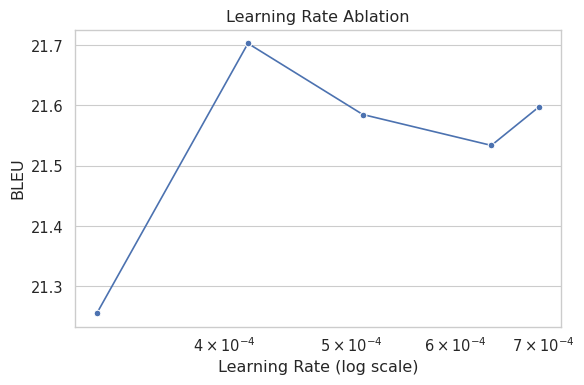

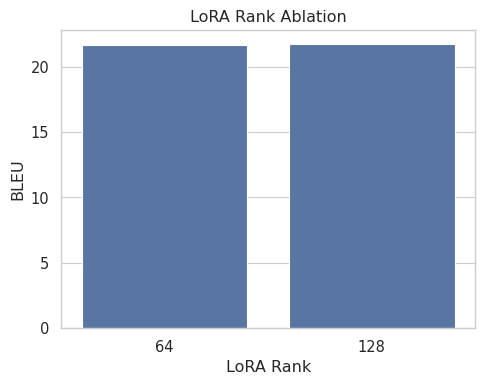

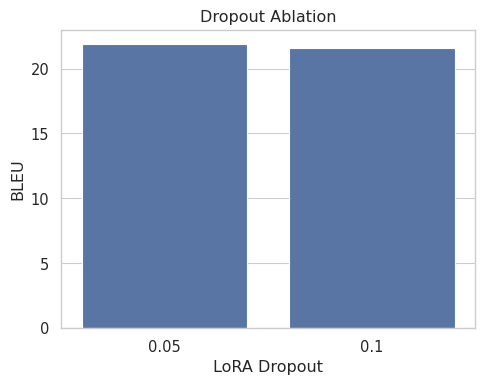

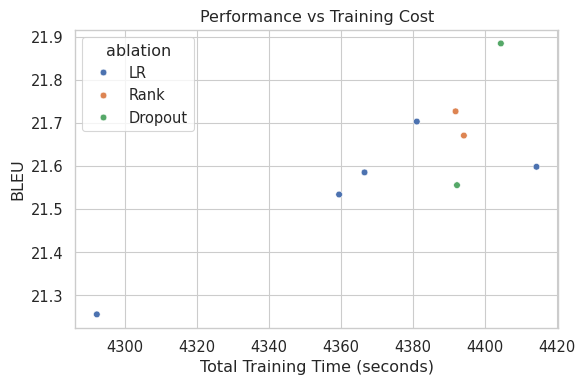

In [ ]:
# Plots
import matplotlib.pyplot as plt
import seaborn as sns

# styling
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# BLEU vs Learning Rate
plt.figure(figsize=(6,4))
sns.lineplot(data=df_lr, x="learning_rate", y="bleu", marker="o")
plt.xscale("log")
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("BLEU")
plt.title("Learning Rate Ablation")
plt.tight_layout()
plt.savefig("ablation_lr_bleu.pdf")
plt.show()

# BLEU vs Rank
plt.figure(figsize=(5,4))
sns.barplot(data=df_rank, x="r", y="bleu")
plt.xlabel("LoRA Rank")
plt.ylabel("BLEU")
plt.title("LoRA Rank Ablation")
plt.tight_layout()
plt.savefig("ablation_rank_bleu.pdf")
plt.show()

# BLEU vs Dropout
plt.figure(figsize=(5,4))
sns.barplot(data=df_dropout, x="dropout", y="bleu")
plt.xlabel("LoRA Dropout")
plt.ylabel("BLEU")
plt.title("Dropout Ablation")
plt.tight_layout()
plt.savefig("ablation_dropout_bleu.pdf")
plt.show()

# BLEU vs Training Time
df_all = pd.concat([
    df_lr.assign(ablation="LR"),
    df_rank.assign(ablation="Rank"),
    df_dropout.assign(ablation="Dropout"),
])

plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df_all,
    x="total_time_sec",
    y="bleu",
    hue="ablation"
)
plt.xlabel("Total Training Time (seconds)")
plt.ylabel("BLEU")
plt.title("Performance vs Training Cost")
plt.tight_layout()
plt.savefig("bleu_vs_time.pdf")
plt.show()

## Observations


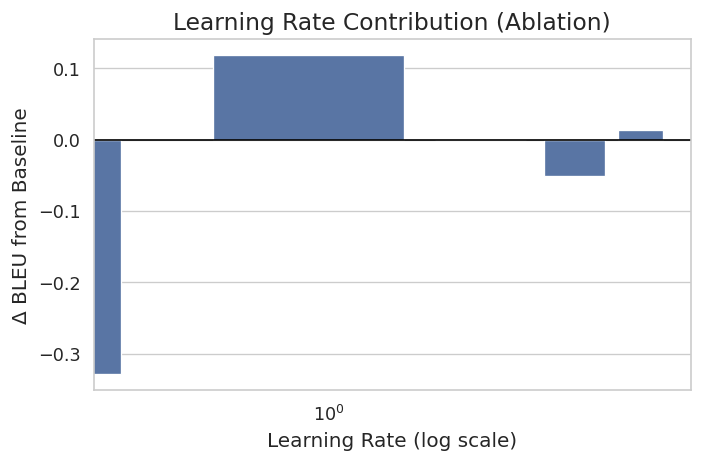

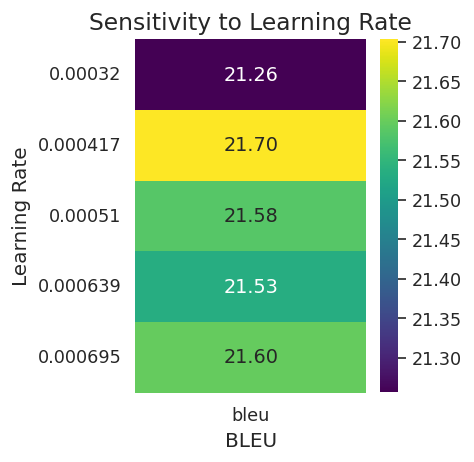

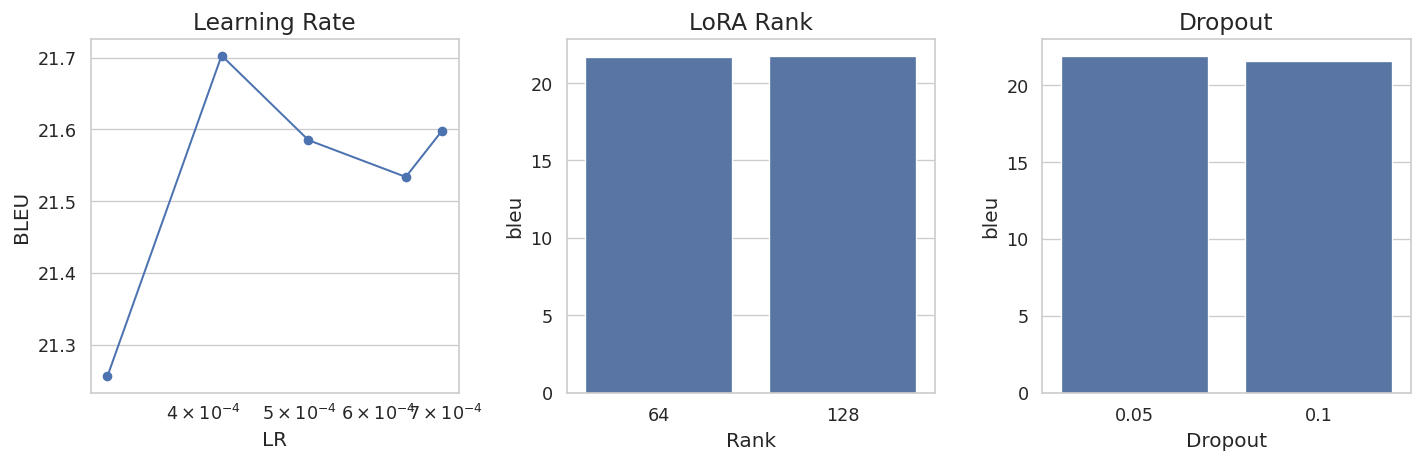

In [ ]:
sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.2
)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
})

# ΔBLEU from Baseline (Causal View)
baseline_bleu = df_lr.loc[
    df_lr["learning_rate"] == 0.000510, "bleu"
].values[0]

df_lr["delta_bleu"] = df_lr["bleu"] - baseline_bleu

plt.figure(figsize=(6, 4))

sns.barplot(
    x="learning_rate",
    y="delta_bleu",
    data=df_lr
)

plt.xscale("log")
plt.axhline(0, color="black", linewidth=1)

plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Δ BLEU from Baseline")
plt.title("Learning Rate Contribution (Ablation)")

plt.tight_layout()
plt.show()

# Heatmap (LR × Parameter Sensitivity)
heatmap_data = df_lr.pivot_table(
    index="learning_rate",
    values="bleu"
)

plt.figure(figsize=(4, 4))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.xlabel("BLEU")
plt.ylabel("Learning Rate")
plt.title("Sensitivity to Learning Rate")

plt.tight_layout()
plt.show()

# Combined Ablation Figure
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# LR
axes[0].plot(df_lr["learning_rate"], df_lr["bleu"], marker="o")
axes[0].set_xscale("log")
axes[0].set_title("Learning Rate")
axes[0].set_xlabel("LR")
axes[0].set_ylabel("BLEU")

# Rank
sns.barplot(x="r", y="bleu", data=df_rank, ax=axes[1], errorbar=None)
axes[1].set_title("LoRA Rank")
axes[1].set_xlabel("Rank")

# Dropout
sns.barplot(x="dropout", y="bleu", data=df_dropout, ax=axes[2], errorbar=None)
axes[2].set_title("Dropout")
axes[2].set_xlabel("Dropout")

plt.tight_layout()
plt.show()